# 🔍 Aseel — Mahally Multimodal (FIXED)

## النسخة المصلَحة من تدريب الموديل

### 🛠️ الإصلاحات المطبَّقة:

1. ✅ **Price Scaling داخل CV loop** — fit على training fold فقط (لا data leakage)
2. ✅ **Brand Encoding داخل CV loop** — fit على training fold فقط
3. ✅ **Class Weights محسوبة من training set فقط** — مش من كل البيانات
4. ✅ **حفظ encoders من الـ fold الأفضل** — للديمو لاحقاً
5. ✅ **Reproducibility** — كل seeds موحدة

**⚠️ Runtime > GPU**

## 📦 Cell 1: Install Dependencies

In [ ]:
!pip install -q torch torchvision transformers easyocr scikit-learn pandas openpyxl matplotlib seaborn tqdm pillow arabert
import warnings
warnings.filterwarnings('ignore')
print('✅ All packages installed!')

✅ All packages installed!


## 📚 Cell 2: Import Libraries

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# Torchvision
import torchvision.transforms as transforms
from torchvision import models

# Transformers (AraBERT)
from transformers import AutoTokenizer, AutoModel

# OCR
import easyocr

# Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, precision_recall_curve
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('✅ All libraries imported!')

🖥️ Device: cuda
   GPU: Tesla T4
✅ All libraries imported!


## 📂 Cell 3: Mount Drive & Setup Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive'
DATA_PATH = BASE_PATH
EXCEL_FILE = '/content/drive/MyDrive/GP1 (أصيل)/Data/mahally_final_preprocessed.xlsx'
IMAGES_BASE = '/content/drive/MyDrive/GP1 (أصيل)/Data/mahally_images'

print(f'📊 Excel exists: {os.path.exists(EXCEL_FILE)}')
print(f'📁 Images folder exists: {os.path.exists(IMAGES_BASE)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Excel exists: True
📁 Images folder exists: True


## 📊 Cell 4: Load Data

In [ ]:
data = pd.read_excel(EXCEL_FILE)
print(f'📦 Total products: {len(data)}')
print(f'   Fake: {(data["is_authentic"]==0).sum()}')
print(f'   Real: {(data["is_authentic"]==1).sum()}')

# Combine name + description
data['combined_text'] = data['productName'].fillna('').astype(str) + ' ' + data['description'].fillna('no_desc').astype(str)

# Pre-compute price_log (safe - no leakage, just math transform)
data['price_log'] = np.log1p(data['price'])

print('\n✅ Data loaded!')

📦 Total products: 2740
   Fake: 1369
   Real: 1371

✅ Data loaded!


## 🖼️ Cell 5: Build Image Mapping

In [ ]:
product_images = {}
valid_ext = {'.jpg', '.jpeg', '.png', '.webp'}
total_found = 0

print('🔍 Scanning image folders...')
for brand_dir in sorted(os.listdir(IMAGES_BASE)):
    brand_path = os.path.join(IMAGES_BASE, brand_dir)
    if not os.path.isdir(brand_path):
        continue
    for label in ['real', 'fake']:
        label_path = os.path.join(brand_path, label)
        if not os.path.exists(label_path):
            continue
        count = 0
        for fname in os.listdir(label_path):
            ext = os.path.splitext(fname)[1].lower()
            if ext not in valid_ext:
                continue
            try:
                pid = int(os.path.splitext(fname)[0])
                product_images[pid] = os.path.join(label_path, fname)
                count += 1
            except ValueError:
                continue
        total_found += count

print(f'📊 Total images: {total_found}')
before = len(data)
data = data[data['Id'].isin(product_images.keys())].reset_index(drop=True)
print(f'✅ Working dataset: {before} → {len(data)} products (with images)')

🔍 Scanning image folders...
📊 Total images: 2477
✅ Working dataset: 2740 → 2477 products (with images)


## 🔤 Cell 6: OCR Extraction

In [ ]:
print('🔤 Initializing EasyOCR...')
reader = easyocr.Reader(['ar', 'en'], gpu=torch.cuda.is_available())

def extract_ocr(image_path):
    try:
        results = reader.readtext(image_path, detail=0)
        return ' '.join(results) if results else 'no_text'
    except Exception:
        return 'no_text'

print('📝 Extracting OCR text from images...')
ocr_texts = {}
for pid in tqdm(data['Id'].tolist(), desc='OCR'):
    img_path = product_images.get(pid)
    if img_path:
        ocr_texts[pid] = extract_ocr(img_path)
    else:
        ocr_texts[pid] = 'no_text'

data['ocr_text'] = data['Id'].map(ocr_texts)
has_text = (data['ocr_text'] != 'no_text').sum()
print(f'\n✅ OCR Complete! {has_text}/{len(data)} with text')

🔤 Initializing EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete📝 Extracting OCR text from images...


OCR: 100%|██████████| 2477/2477 [14:33<00:00,  2.84it/s]


✅ OCR Complete! 1036/2477 with text


## ⚙️ Cell 7: Feature Setup (NO FITTING HERE!)

**🛠️ الإصلاح المهم**: ما نعمل `fit_transform` على كل البيانات. فقط نحدد الـ feature names. الـ scaling والـ encoding بيتم داخل CV loop.

In [ ]:
# ⚠️ NO fit_transform here! Just define feature names.
tabular_features = ['price_scaled', 'brand_encoded']

# Quick info
n_brands = data['brand'].nunique()
print(f'📊 Tabular Features: {tabular_features}')
print(f'   Unique brands: {n_brands}')
print(f'   Price range (raw): [{data["price"].min():.2f}, {data["price"].max():.2f}]')
print(f'   Price range (log): [{data["price_log"].min():.2f}, {data["price_log"].max():.2f}]')
print()
print('🛠️ FIX: Scaling & encoding will be done INSIDE the CV loop (per-fold)')
print('   → This eliminates data leakage from test set into scaler/encoder')

📊 Tabular Features: ['price_scaled', 'brand_encoded']
   Unique brands: 8
   Price range (raw): [90.00, 29700.00]
   Price range (log): [4.51, 10.30]

🛠️ FIX: Scaling & encoding will be done INSIDE the CV loop (per-fold)
   → This eliminates data leakage from test set into scaler/encoder


## 📦 Cell 8: Custom Dataset Class

In [ ]:
class MahallyDataset(Dataset):
    def __init__(self, dataframe, product_images_dict, tokenizer,
                 tabular_features, img_transform=None, max_len=256):
        self.data = dataframe.reset_index(drop=True)
        self.product_images = product_images_dict
        self.tokenizer = tokenizer
        self.tabular_features = tabular_features
        self.img_transform = img_transform
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        product_id = row['Id']

        # 1. Image
        img_path = self.product_images.get(product_id)
        try:
            if img_path and os.path.exists(img_path):
                img = Image.open(img_path).convert('RGB')
                if self.img_transform:
                    img = self.img_transform(img)
            else:
                img = torch.zeros(3, 224, 224)
        except Exception:
            img = torch.zeros(3, 224, 224)

        # 2. Tabular
        tab = torch.tensor(row[self.tabular_features].values.astype(np.float32))

        # 3. Text
        text_encoding = self.tokenizer(
            str(row['combined_text']), max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )

        # 4. OCR
        ocr_encoding = self.tokenizer(
            str(row['ocr_text']), max_length=128,
            padding='max_length', truncation=True, return_tensors='pt'
        )

        label = torch.tensor(row['is_authentic'], dtype=torch.float32)

        return {
            'image': img,
            'tabular': tab,
            'text_input_ids': text_encoding['input_ids'].squeeze(0),
            'text_attention_mask': text_encoding['attention_mask'].squeeze(0),
            'ocr_input_ids': ocr_encoding['input_ids'].squeeze(0),
            'ocr_attention_mask': ocr_encoding['attention_mask'].squeeze(0),
            'label': label,
            'product_id': product_id
        }

print('✅ Dataset class defined!')

✅ Dataset class defined!


## 🧠 Cell 9: Model Architecture

In [ ]:
ARABERT_MODEL = 'aubmindlab/bert-base-arabertv02'

class MahallyModel(nn.Module):
    def __init__(self, num_tabular_features=2, freeze_bert_layers=10, freeze_efficientnet=True):
        super(MahallyModel, self).__init__()

        # 1. Image: EfficientNet-B0
        efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze_efficientnet:
            for param in efficientnet.parameters():
                param.requires_grad = False
            for param in efficientnet.features[-2:].parameters():
                param.requires_grad = True
        self.image_backbone = efficientnet.features
        self.image_pool = nn.AdaptiveAvgPool2d(1)

        # 2. Tabular
        self.tabular_branch = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
        )

        # 3. Text: AraBERT
        self.text_bert = AutoModel.from_pretrained(ARABERT_MODEL)
        for i, layer in enumerate(self.text_bert.encoder.layer):
            if i < freeze_bert_layers:
                for param in layer.parameters():
                    param.requires_grad = False

        # 4. OCR projection
        self.ocr_projection = nn.Linear(768, 768)

        # 5. Classifier
        fusion_dim = 1280 + 32 + 768 + 768  # 2848
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular, text_input_ids, text_attention_mask,
                ocr_input_ids, ocr_attention_mask):
        img_features = self.image_backbone(image)
        img_out = self.image_pool(img_features).squeeze(-1).squeeze(-1)
        tab_out = self.tabular_branch(tabular)
        text_out = self.text_bert(input_ids=text_input_ids,
                                   attention_mask=text_attention_mask).pooler_output
        ocr_out = self.ocr_projection(
            self.text_bert(input_ids=ocr_input_ids,
                           attention_mask=ocr_attention_mask).pooler_output
        )
        fused = torch.cat([img_out, tab_out, text_out, ocr_out], dim=1)
        return self.classifier(fused).squeeze(1)

# Test
test_model = MahallyModel(num_tabular_features=len(tabular_features)).to(device)
total = sum(p.numel() for p in test_model.parameters())
trainable = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f'🧠 Model created!')
print(f'   Total: {total:,}')
print(f'   Trainable: {trainable:,}')
del test_model; torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s] 


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🧠 Model created!
   Total: 141,319,709
   Trainable: 67,562,833


## 🏋️ Cell 10: Training & Evaluation Functions

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                model.load_state_dict(self.best_model_state)
                print(f'  ⏹️ Early stopping! Best loss: {self.best_loss:.4f}')
        else:
            self.best_loss = val_loss
            self.best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in dataloader:
        image = batch['image'].to(device)
        tabular = batch['tabular'].to(device)
        t_ids = batch['text_input_ids'].to(device)
        t_mask = batch['text_attention_mask'].to(device)
        o_ids = batch['ocr_input_ids'].to(device)
        o_mask = batch['ocr_attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(image, tabular, t_ids, t_mask, o_ids, o_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(labels)
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, [1 if p > 0.5 else 0 for p in all_preds])
    return avg_loss, acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in dataloader:
            image = batch['image'].to(device)
            tabular = batch['tabular'].to(device)
            t_ids = batch['text_input_ids'].to(device)
            t_mask = batch['text_attention_mask'].to(device)
            o_ids = batch['ocr_input_ids'].to(device)
            o_mask = batch['ocr_attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(image, tabular, t_ids, t_mask, o_ids, o_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * len(labels)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend([1 if p > 0.5 else 0 for p in probs])
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, f1, auc, all_labels, all_preds, all_probs

print('✅ Training functions defined!')

✅ Training functions defined!


## 🔧 Cell 11: Transforms & Tokenizer

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('Loading AraBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(ARABERT_MODEL)
print('✅ Transforms & tokenizer ready!')

Loading AraBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Transforms & tokenizer ready!


## 🔄 Cell 12: 5-Fold Cross-Validation (FIXED — No Data Leakage!)

### 🛠️ الإصلاحات في هذي الخلية:

1. **Price Scaling** يتم داخل كل fold (fit على train فقط)
2. **Brand Encoding** يتم داخل كل fold (fit على train فقط)
3. **Class Weights** محسوبة من training set في كل fold
4. **حفظ encoders** من الـ fold الأفضل (للديمو)

⏰ المدة المتوقعة: 3-5 ساعات

In [ ]:
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 7
N_FOLDS = 5

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X = data.index.values
y = data['is_authentic'].values

fold_results = []
best_auc = 0
best_model_state = None
best_fold_val_loader = None
best_fold_val_data = None
best_le_brand = None        # 🛠️ FIX: save encoders from best fold
best_price_scaler = None    # 🛠️ FIX: save scaler from best fold
train_losses = []
val_losses = []

print('=' * 70)
print(f'  🔄 5-FOLD CROSS-VALIDATION (FIXED — No Data Leakage)')
print(f'  Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print('=' * 70)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'\n{"─"*50}')
    print(f'  📂 FOLD {fold+1}/{N_FOLDS}')
    print(f'{"─"*50}')

    # Split data (copy to avoid modifying original)
    train_cv = data.iloc[train_idx].copy()
    val_cv = data.iloc[val_idx].copy()

    # ============================================================
    # 🛠️ FIX #1: Brand Encoding — fit on TRAIN only
    # ============================================================
    le_brand_fold = LabelEncoder()
    le_brand_fold.fit(train_cv['brand'].astype(str))
    train_cv['brand_encoded'] = le_brand_fold.transform(train_cv['brand'].astype(str))

    # Handle unseen brands in val (use first class as default)
    known_brands = set(le_brand_fold.classes_)
    val_brands = val_cv['brand'].astype(str)
    unseen_mask = ~val_brands.isin(known_brands)
    if unseen_mask.any():
        print(f'  ⚠️ {unseen_mask.sum()} val samples have unseen brands (using fallback)')
        val_brands = val_brands.where(~unseen_mask, le_brand_fold.classes_[0])
    val_cv['brand_encoded'] = le_brand_fold.transform(val_brands)

    # ============================================================
    # 🛠️ FIX #2: Price Scaling — fit on TRAIN only
    # ============================================================
    price_scaler_fold = StandardScaler()
    train_cv['price_scaled'] = price_scaler_fold.fit_transform(train_cv[['price_log']])
    val_cv['price_scaled'] = price_scaler_fold.transform(val_cv[['price_log']])

    # ============================================================
    # 🛠️ FIX #3: Class Weights from TRAIN only
    # ============================================================
    num_fake_train = (train_cv['is_authentic']==0).sum()
    num_real_train = (train_cv['is_authentic']==1).sum()
    pos_weight = torch.tensor([num_fake_train / num_real_train]).to(device)

    print(f'  Train: {len(train_cv)} ({num_fake_train} fake, {num_real_train} real)')
    print(f'  Val:   {len(val_cv)} ({(val_cv["is_authentic"]==0).sum()} fake, {(val_cv["is_authentic"]==1).sum()} real)')
    print(f'  Price scaling fit on TRAIN only: mean={price_scaler_fold.mean_[0]:.3f}, scale={price_scaler_fold.scale_[0]:.3f}')
    print(f'  pos_weight (from TRAIN): {pos_weight.item():.3f}')

    # ============================================================
    # Create datasets & loaders
    # ============================================================
    train_ds = MahallyDataset(train_cv, product_images, tokenizer, tabular_features, train_transform)
    val_ds = MahallyDataset(val_cv, product_images, tokenizer, tabular_features, val_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # Model
    model = MahallyModel(num_tabular_features=len(tabular_features)).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    early_stop = EarlyStopping(patience=PATIENCE)

    fold_train_l, fold_val_l = [], []

    for epoch in range(EPOCHS):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va, vf, vauc, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl)
        fold_train_l.append(tl)
        fold_val_l.append(vl)

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:2d} | Train: {tl:.4f}/{ta:.4f} | Val: {vl:.4f}/{va:.4f}/F1:{vf:.4f}/AUC:{vauc:.4f}')

        early_stop(vl, model)
        if early_stop.early_stop:
            break

    _, va, vf, vauc, labels, preds, probs = evaluate(model, val_loader, criterion, device)
    fold_results.append({'fold': fold+1, 'accuracy': va, 'f1': vf, 'auc': vauc})
    print(f'  📊 Fold {fold+1}: Acc={va:.4f} | F1={vf:.4f} | AUC={vauc:.4f}')

    if vauc > best_auc:
        best_auc = vauc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        best_fold_val_loader = val_loader
        best_fold_val_data = val_cv
        best_le_brand = le_brand_fold        # 🛠️ FIX: save
        best_price_scaler = price_scaler_fold  # 🛠️ FIX: save
        best_pos_weight = pos_weight
        train_losses = fold_train_l
        val_losses = fold_val_l
        print(f'  🏆 New best! AUC: {vauc:.4f}')

    del model, optimizer, scheduler
    torch.cuda.empty_cache()

# Load best model
final_model = MahallyModel(num_tabular_features=len(tabular_features)).to(device)
final_model.load_state_dict(best_model_state)
test_loader = best_fold_val_loader
test_data = best_fold_val_data
le_brand = best_le_brand
price_scaler = best_price_scaler
pos_weight = best_pos_weight

# Summary
print('\n' + '=' * 70)
print('  📊 5-FOLD CV SUMMARY (FIXED — No Data Leakage)')
print('=' * 70)
results_df = pd.DataFrame(fold_results)
print(f'  Accuracy: {results_df["accuracy"].mean():.4f} ± {results_df["accuracy"].std():.4f}')
print(f'  F1:       {results_df["f1"].mean():.4f} ± {results_df["f1"].std():.4f}')
print(f'  AUC-ROC:  {results_df["auc"].mean():.4f} ± {results_df["auc"].std():.4f}')
print(f'\n{results_df.to_string(index=False)}')
print(f'\n🏆 Best Fold AUC: {best_auc:.4f} → loaded as final_model')
print(f'🔒 Encoders saved from best fold for deployment')

  🔄 5-FOLD CROSS-VALIDATION (FIXED — No Data Leakage)
  Epochs: 20 | Batch: 16 | LR: 2e-05

──────────────────────────────────────────────────
  📂 FOLD 1/5
──────────────────────────────────────────────────
  Train: 1981 (1056 fake, 925 real)
  Val:   496 (265 fake, 231 real)
  Price scaling fit on TRAIN only: mean=6.963, scale=1.494
  pos_weight (from TRAIN): 1.142


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1 | Train: 0.4256/0.8304 | Val: 0.2062/0.9375/F1:0.9342/AUC:0.9921
  Epoch  5 | Train: 0.0955/0.9838 | Val: 0.0914/0.9778/F1:0.9758/AUC:0.9992
  Epoch 10 | Train: 0.0652/0.9894 | Val: 0.0621/0.9859/F1:0.9848/AUC:0.9995
  Epoch 15 | Train: 0.0367/0.9965 | Val: 0.0677/0.9819/F1:0.9803/AUC:0.9994
  ⏹️ Early stopping! Best loss: 0.0568
  📊 Fold 1: Acc=0.9839 | F1=0.9826 | AUC=0.9995
  🏆 New best! AUC: 0.9995

──────────────────────────────────────────────────
  📂 FOLD 2/5
──────────────────────────────────────────────────
  Train: 1981 (1057 fake, 924 real)
  Val:   496 (264 fake, 232 real)
  Price scaling fit on TRAIN only: mean=6.975, scale=1.495
  pos_weight (from TRAIN): 1.144


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1 | Train: 0.4250/0.8471 | Val: 0.1677/0.9636/F1:0.9623/AUC:0.9967
  Epoch  5 | Train: 0.1008/0.9874 | Val: 0.0614/0.9919/F1:0.9913/AUC:0.9999
  Epoch 10 | Train: 0.0576/0.9939 | Val: 0.0442/0.9919/F1:0.9913/AUC:0.9999
  Epoch 15 | Train: 0.0331/0.9960 | Val: 0.0392/0.9919/F1:0.9913/AUC:0.9999
  Epoch 20 | Train: 0.0276/0.9975 | Val: 0.0262/0.9939/F1:0.9935/AUC:0.9999
  📊 Fold 5: Acc=0.9939 | F1=0.9935 | AUC=0.9999


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  📊 5-FOLD CV SUMMARY (FIXED — No Data Leakage)
  Accuracy: 0.9887 ± 0.0058
  F1:       0.9878 ± 0.0063
  AUC-ROC:  0.9997 ± 0.0002

 fold  accuracy       f1      auc
    1  0.983871 0.982609 0.999543
    2  0.985887 0.984816 0.999592
    3  0.983838 0.982609 0.999475
    4  0.995960 0.995671 0.999951
    5  0.993939 0.993521 0.999934

🏆 Best Fold AUC: 1.0000 → loaded as final_model
🔒 Encoders saved from best fold for deployment


## 📊 Cell 13: Test Results & Visualizations

  📊 BEST FOLD TEST RESULTS (FIXED)
  Accuracy: 0.9960
  F1:       0.9957
  AUC-ROC:  1.0000

              precision    recall  f1-score   support

 Counterfeit       1.00      1.00      1.00       264
   Authentic       1.00      1.00      1.00       231

    accuracy                           1.00       495
   macro avg       1.00      1.00      1.00       495
weighted avg       1.00      1.00      1.00       495



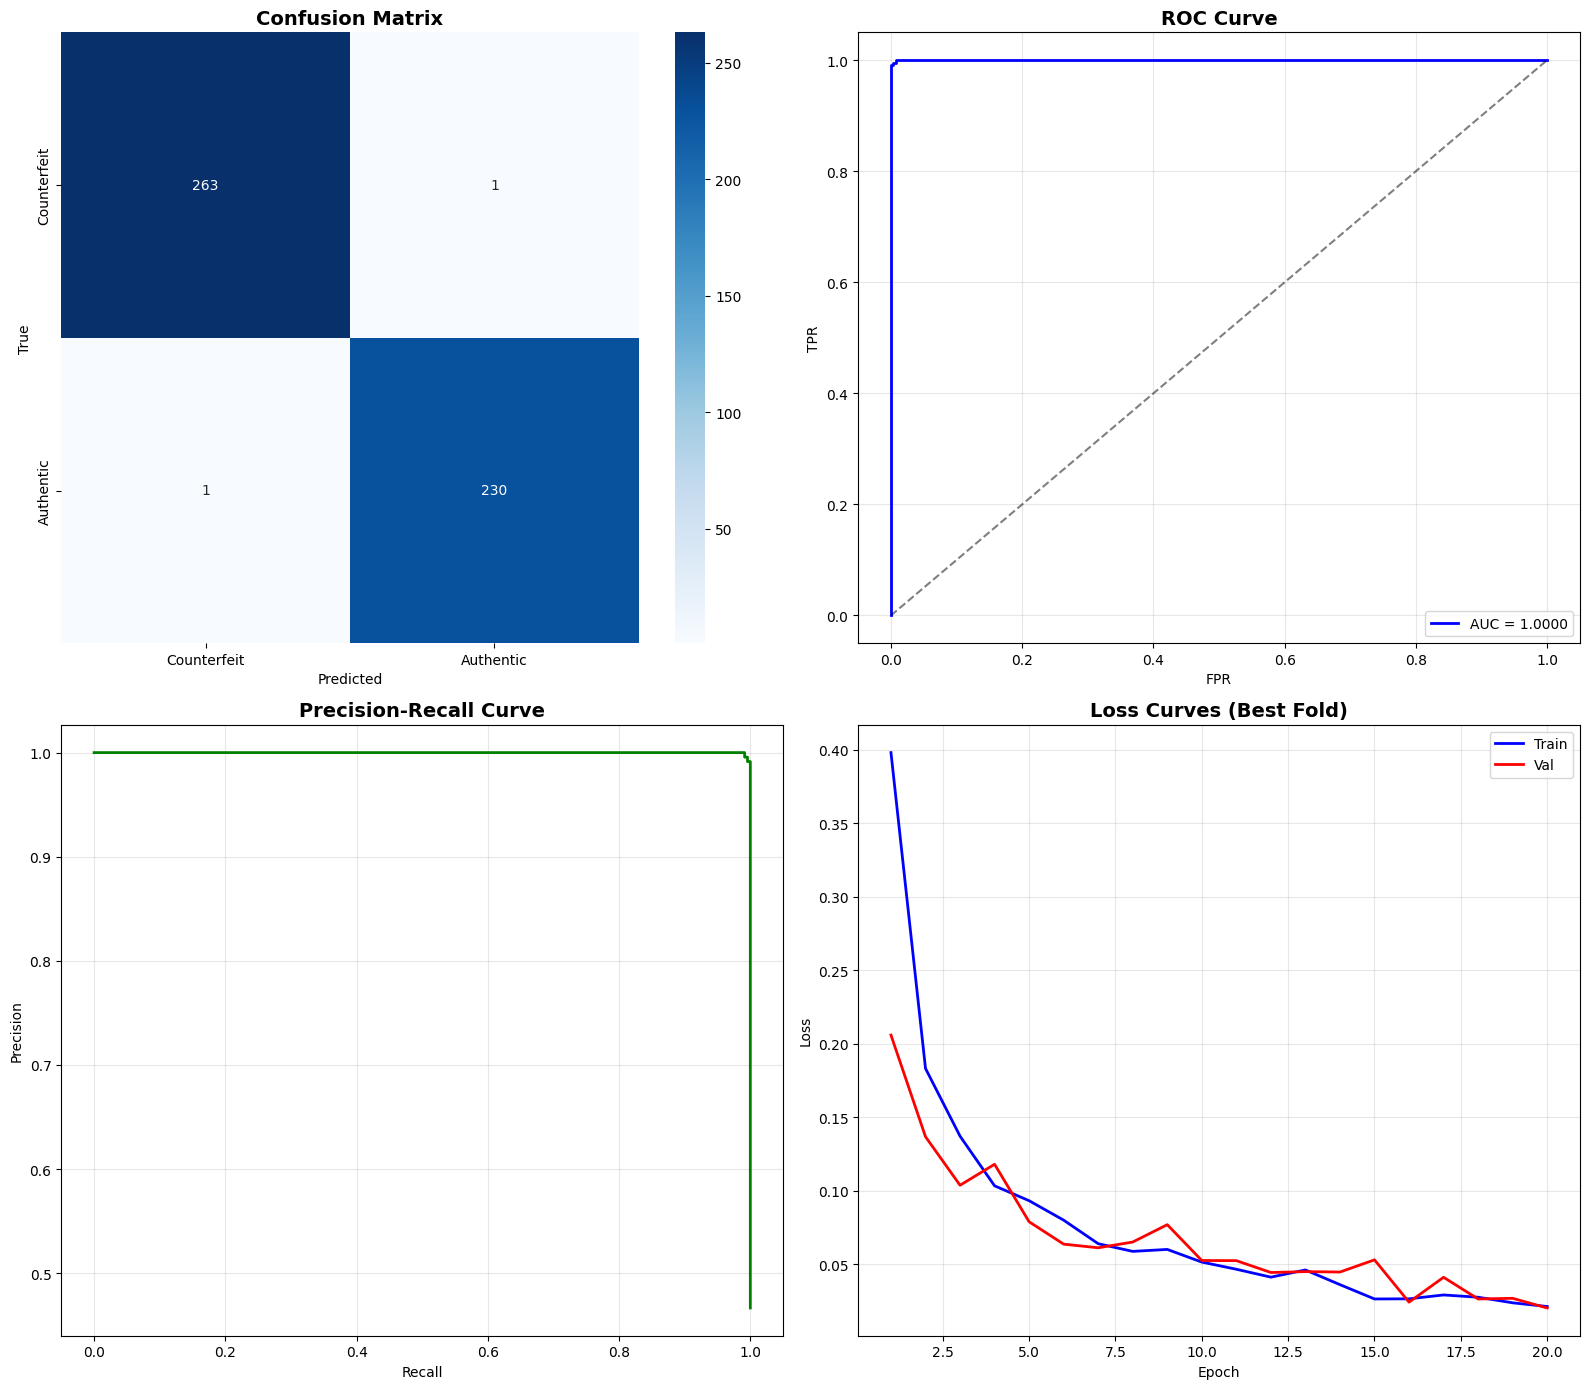

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
test_loss, test_acc, test_f1, test_auc, y_true, y_pred, y_prob = evaluate(final_model, test_loader, criterion, device)

print('=' * 70)
print('  📊 BEST FOLD TEST RESULTS (FIXED)')
print('=' * 70)
print(f'  Accuracy: {test_acc:.4f}')
print(f'  F1:       {test_f1:.4f}')
print(f'  AUC-ROC:  {test_auc:.4f}')
print(f'\n{classification_report(y_true, y_pred, target_names=["Counterfeit","Authentic"])}')

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Counterfeit','Authentic'], yticklabels=['Counterfeit','Authentic'])
axes[0,0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('True'); axes[0,0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0,1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {test_auc:.4f}')
axes[0,1].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
axes[0,1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_true, y_prob)
axes[1,0].plot(rec, prec, 'g-', lw=2)
axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1,0].grid(alpha=0.3)

axes[1,1].plot(range(1, len(train_losses)+1), train_losses, 'b-', lw=2, label='Train')
axes[1,1].plot(range(1, len(val_losses)+1), val_losses, 'r-', lw=2, label='Val')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss')
axes[1,1].set_title('Loss Curves (Best Fold)', fontsize=14, fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'Mahally_results_FIXED.png'), dpi=300, bbox_inches='tight')
plt.show()

## 📊 Cell 14: Per-Brand Results

In [ ]:
final_model.eval()
brand_results = []

with torch.no_grad():
    for batch in test_loader:
        image = batch['image'].to(device)
        tabular = batch['tabular'].to(device)
        t_ids = batch['text_input_ids'].to(device)
        t_mask = batch['text_attention_mask'].to(device)
        o_ids = batch['ocr_input_ids'].to(device)
        o_mask = batch['ocr_attention_mask'].to(device)
        labels = batch['label']
        pids = batch['product_id']

        outputs = final_model(image, tabular, t_ids, t_mask, o_ids, o_mask)
        probs = torch.sigmoid(outputs).cpu().numpy()

        for pid, lbl, prob in zip(pids, labels.numpy(), probs):
            brand_results.append({
                'Id': pid.item() if torch.is_tensor(pid) else pid,
                'true': lbl, 'pred': 1 if prob > 0.5 else 0, 'prob': prob
            })

brand_df = pd.DataFrame(brand_results).merge(data[['Id','brand']], on='Id')

print('=' * 70)
print('  📊 PER-BRAND RESULTS (FIXED)')
print('=' * 70)

brand_metrics = []
for brand in sorted(brand_df['brand'].unique()):
    b = brand_df[brand_df['brand']==brand]
    if len(b) < 2: continue
    acc = accuracy_score(b['true'], b['pred'])
    f1_b = f1_score(b['true'], b['pred'], zero_division=0)
    try: auc_b = roc_auc_score(b['true'], b['prob'])
    except: auc_b = 0
    brand_metrics.append({'Brand': brand, 'N': len(b), 'Accuracy': acc, 'F1': f1_b, 'AUC': auc_b})
    print(f'  {brand:15s} | N={len(b):3d} | Acc={acc:.4f} | F1={f1_b:.4f} | AUC={auc_b:.4f}')

## 💾 Cell 15: Save Model & Artifacts

In [ ]:
SAVE_PATH = os.path.join(DATA_PATH, 'Mahally_model_FIXED')
os.makedirs(SAVE_PATH, exist_ok=True)

torch.save({
    'model_state_dict': final_model.state_dict(),
    'num_tabular_features': len(tabular_features),
    'tabular_features': tabular_features,
    'epochs_trained': len(train_losses),
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'data_leakage_fixed': True,
}, os.path.join(SAVE_PATH, 'mahally_model.pth'))

# 🛠️ Save encoders from BEST FOLD ONLY (no leakage)
with open(os.path.join(SAVE_PATH, 'encoders.pkl'), 'wb') as f:
    pickle.dump({
        'brand_encoder': le_brand,      # from best fold's train
        'le_brand': le_brand,            # alias for compatibility
        'price_scaler': price_scaler,    # from best fold's train
        'tabular_features': tabular_features,
        'note': 'Encoders fit ONLY on best fold training data (no leakage)'
    }, f)

with open(os.path.join(SAVE_PATH, 'training_results.pkl'), 'wb') as f:
    pickle.dump({
        'cv_results': fold_results,
        'test_results': {'accuracy': test_acc, 'f1': test_f1, 'auc': test_auc,
                         'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob},
        'train_losses': train_losses, 'val_losses': val_losses,
        'brand_metrics': brand_metrics,
    }, f)

torch.save(final_model, os.path.join(SAVE_PATH, 'mahally_full_model.pth'))

print('=' * 70)
print(f'  💾 SAVED TO: {SAVE_PATH}')
print('=' * 70)
print('  📁 mahally_model.pth        → weights + metadata (FIXED)')
print('  📁 mahally_full_model.pth   → complete model')
print('  📁 encoders.pkl             → encoders from BEST FOLD only')
print('  📁 training_results.pkl     → all metrics')
print(f'\n📊 Final Results:')
print(f'   Accuracy: {test_acc:.4f}')
print(f'   F1-Score: {test_f1:.4f}')
print(f'   AUC-ROC:  {test_auc:.4f}')